# The ProtoQol

Every project lives and dies based on its libraries.

In [37]:
# Avoid overcommmitting memory.
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
# %env XLA_PYTHON_CLIENT_ALLOCATOR=platform

# Essential libraries.
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Tuple
import math
import random
import warnings

# Generic scientific computing.
import numpy as np
import scipy.optimize as opt

# Machine learning.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

# Quantum dynamics.
import dynamiqs as dq
import jax.numpy as jnp


env: XLA_PYTHON_CLIENT_PREALLOCATE=false


Compactly retain all the tuning parameters in a single object

In [38]:
@dataclass
class CatConfig:
	# Hilbert cutoffs.
	na: int = 10
	nb: int = 3

	# Non-optimized hardware rates.
	kappa_b: float = 10.0
	kappa_a: float = 0.05
	# Default initial configuration.
	default_knobs: Tuple[float, float] = (1.0, 4.0)

	# Time grids.
	t_stabilize: float = 8.0
	n_stabilize: int = 80
	t_life_z: float = 80.0
	t_life_x: float = 20.0
	n_life: int = 60

	# Discovery grid for the Husimi-Q function.
	q_radius: float = 3.5
	q_grid_n: int = 32
	min_blob_separation: float = 0.25

	# Targeted logical bias eta = Tz / Tx.
	target_eta: float = 10.0

	# Reward shaping.
	w_lifetime: float = 1.0
	w_bias: float = 0.4
	# w_cat_quality: float = 0.2
	w_penalty: float = 1.0

	# Numerical safeguards.
	min_T: float = 1e-3
	max_T: float = 1e4
	max_photon_fraction: float = 0.75  # penalize if <n_a> approaches cutoff.
	max_buffer_occupation: float = 1.5

	# Bounds for the four real knobs.
	# x = [g2, eps_d]
	low: Tuple[float, float] = (-3.0, -8.0)
	high: Tuple[float, float] = (3.0, 8.0)

	# PPO environment.
	action_scale: float = 0.15	  # action step in normalized knob coordinates.
	drift_std: float = 0.01		 # random-walk drift in normalized coordinates.
	episode_len: int = 8

@dataclass
class PPOConfig:
	seed: int = 42
	total_updates: int = 30
	rollout_steps: int = 16
	ppo_epochs: int = 4
	minibatch_size: int = 16
	gamma: float = 0.95
	gae_lambda: float = 0.90
	clip_coef: float = 0.20
	value_coef: float = 0.50
	# Encourage exploration.
	entropy_coef: float = 0.04
	lr: float = 2e-4
	max_grad_norm: float = 0.5

Faciliatting helper utilities.

In [39]:
def set_seed(seed: int) -> None:
	random.seed(seed)
	np.random.seed(seed)
	torch.manual_seed(seed)

def as_np(x) -> np.ndarray:
	"""Convert Dynamiqs/JAX/Numpy object to numpy."""
	try:
		return dq.to_numpy(x)
	except Exception:
		return np.asarray(x)

def normalize_knobs(x: np.ndarray, cfg: CatConfig) -> np.ndarray:
	low = np.asarray(cfg.low, dtype=np.float64)
	high = np.asarray(cfg.high, dtype=np.float64)
	return 2.0 * (x - low) / (high - low) - 1.0

def denormalize_knobs(z: np.ndarray, cfg: CatConfig) -> np.ndarray:
	low = np.asarray(cfg.low, dtype=np.float64)
	high = np.asarray(cfg.high, dtype=np.float64)
	z = np.clip(z, -1.0, 1.0)
	return low + 0.5 * (z + 1.0) * (high - low)

def exp_model(t: np.ndarray, a: float, T: float, c: float) -> np.ndarray:
	return a * np.exp(-t / max(T, 1e-12)) + c

def robust_exp_fit(t: np.ndarray, y: np.ndarray, cfg: CatConfig) -> float:
	"""Fit y(t) = a exp(-t/T) + c. Returns T with safeguards."""
	t = np.asarray(t, dtype=np.float64)
	y = np.asarray(y, dtype=np.float64)
	mask = np.isfinite(t) & np.isfinite(y)
	t, y = t[mask], y[mask]
	if len(t) < 5 or np.std(y) < 1e-8:
		return cfg.min_T

	# Normalize sign so the dominant signal decays from positive amplitude.
	if abs(y[0]) > 1e-9 and y[0] < 0:
		y = -y

	amp0 = float(y[0] - y[-1])
	c0 = float(y[-1])
	T0 = max(float((t[-1] - t[0]) / 3.0), cfg.min_T)

	try:
		popt, _ = opt.curve_fit(
			exp_model,
			t,
			y,
			p0=[amp0, T0, c0],
			bounds=([-5.0, cfg.min_T, -2.0], [5.0, cfg.max_T, 2.0]),
			maxfev=5000,
		)
		T = float(popt[1])
		if not np.isfinite(T):
			return cfg.min_T
		return float(np.clip(T, cfg.min_T, cfg.max_T))
	except Exception:
		return cfg.min_T

def ket_to_dm(ket_np: np.ndarray) -> np.ndarray:
	ket_np = ket_np.reshape((-1, 1))
	return ket_np @ ket_np.conj().T

def normalize_ket(v: np.ndarray) -> np.ndarray:
	n = np.linalg.norm(v)
	if n < 1e-12:
		raise ValueError("Cannot normalize near-zero ket.")
	return v / n

Cat qubit control class. The pertinent coherent state is identified as the most prominent lobe in the Hushimi Q representation and the objective function scales as given below $$\textrm{reward} = w_{\textrm{lifetime}} \log\sqrt{T_Z T_X} - w_{\textrm{bias}} (\log \frac{\eta}{\eta_{\textrm{target}}})^2 - w_{\textrm{truncation}} [(\langle n_a \rangle - \textrm{ratio}_a)^2 + (\langle n_b \rangle - \textrm{ratio}_b)^2]$$

In [40]:
class FullCatEvaluator:
	def __init__(self, cfg: CatConfig):
		self.cfg = cfg
		self.na = cfg.na
		self.nb = cfg.nb

		self.a = dq.tensor(dq.destroy(cfg.na), dq.eye(cfg.nb))
		self.b = dq.tensor(dq.eye(cfg.na), dq.destroy(cfg.nb))
		self.n_a = self.a.dag() @ self.a
		self.n_b = self.b.dag() @ self.b
		self.loss_a = jnp.sqrt(cfg.kappa_a) * self.a
		self.loss_b = jnp.sqrt(cfg.kappa_b) * self.b
		# self.parity_a = (1j * jnp.pi * self.a_s.dag() @ self.a_s).expm()

		# Coherent-state grid for manifold discovery.
		xs = np.linspace(0.0, cfg.q_radius, cfg.q_grid_n)
		self.alpha_grid = np.array(xs, dtype=np.complex128)
		self.coherent_grid_np = np.stack(
			[as_np(dq.coherent(cfg.na, alpha)).reshape(-1) for alpha in self.alpha_grid],
			axis=0,
		)

	def build_system(self, knobs: np.ndarray):
		"""Return H, collapse_ops for the full two-mode system."""
		g2 = knobs[0]
		eps_d = knobs[1]

		H = (
			g2 * self.a @ self.a @ self.b.dag()
			+ g2 * self.a.dag() @ self.a.dag() @ self.b
			- eps_d * self.b.dag()
			- eps_d * self.b
		)
		c_ops = [self.loss_a, self.loss_b]
		return H, c_ops

	def simulate_final_storage_state(self, knobs: np.ndarray):
		"""Simulate full system from vacuum and return reduced storage state rho_a."""
		H, c_ops = self.build_system(knobs)
		ts = jnp.linspace(0.0, self.cfg.t_stabilize, self.cfg.n_stabilize)
		vac_full = dq.tensor(dq.fock(self.na, 0), dq.fock(self.nb, 0))
		res = dq.mesolve(
			H,
			c_ops,
			vac_full,
			ts,
			options=dq.Options(progress_meter=False)
		)
		final_full = res.states[-1]
		rho_a = dq.ptrace(final_full, 0)
		return rho_a, final_full

	def husimi_q(self, rho_a_np: np.ndarray) -> np.ndarray:
		"""Husimi-Q values on the predefined coherent-state grid."""
		# q_i = <alpha_i|rho|alpha_i>/pi
		vals = np.einsum("ai,ij,aj->a", self.coherent_grid_np.conj(), rho_a_np, self.coherent_grid_np)
		vals = np.real(vals) / np.pi
		return vals

	def discover_cat_manifold(self, knobs: np.ndarray) -> Dict[str, object]:
		"""
		Discover the logical cat basis from the full physical state.

		No use of eps_d/g2. The two logical Z blobs are selected as two separated maxima
		of the storage-mode Husimi-Q landscape. The corresponding coherent states are
		then orthonormalized to construct logical observables.
		"""
		rho_a, final_full = self.simulate_final_storage_state(knobs)
		rho_a_np = as_np(rho_a)
		q = self.husimi_q(rho_a_np)

		order = np.argsort(q)[::-1]
		alpha0 = self.alpha_grid[order[0]]
		alpha1 = -alpha0
		# alpha1 = None
		# for idx in order[1:]:
		# 	cand = self.alpha_grid[idx]
		# 	if abs(cand - alpha0) >= self.cfg.min_blob_separation:
		# 		alpha1 = cand
		# 		break
		# if alpha1 is None:
		# 	alpha1 = -alpha0

		# Define the discovered logical coherent states.
		ket0 = as_np(dq.coherent(self.na, complex(alpha0))).reshape(-1)
		ket1 = as_np(dq.coherent(self.na, complex(alpha1))).reshape(-1)
		# ket1_raw = as_np(dq.coherent(self.na, complex(alpha1))).reshape(-1)

		# Gram-Schmidt to avoid non-orthogonality of coherent blobs.
		# e0 = normalize_ket(ket0)
		# ket1 = ket1_raw - np.vdot(e0, ket1_raw) * e0
		# try:
		# 	e1 = normalize_ket(ket1)
		# except ValueError:
		# 	# Degenerate discovery: punish heavily later, but still return a valid basis.
		# 	e1 = np.zeros_like(e0)
		# 	e1[1 if self.na > 1 else 0] = 1.0

		e0 = normalize_ket(ket0)
		e1 = normalize_ket(ket1)
		P0 = ket_to_dm(e0)
		P1 = ket_to_dm(e1)
		Z = P0 - P1
		X = np.outer(e0, e1.conj()) + np.outer(e1, e0.conj())
		Y = -1j * np.outer(e0, e1.conj()) + 1j * np.outer(e1, e0.conj())

		Ib = dq.eye(self.nb)
		# Full-space observables.
		Z_full = dq.tensor(jnp.asarray(Z), Ib)
		X_full = dq.tensor(jnp.asarray(X), Ib)
		Y_full = dq.tensor(jnp.asarray(Y), Ib)

		vac_b = dq.fock(self.nb, 0)
		# Logical initial states.
		plus_z = dq.tensor(jnp.asarray(e0.reshape(-1, 1)), vac_b)
		minus_z = dq.tensor(jnp.asarray(e1.reshape(-1, 1)), vac_b)
		plus_x_storage = normalize_ket(e0 + e1)
		plus_x = dq.tensor(jnp.asarray(plus_x_storage.reshape(-1, 1)), vac_b)
		minus_x_storage = normalize_ket(e0 - e1)
		minus_x = dq.tensor(jnp.asarray(minus_x_storage.reshape(-1, 1)), vac_b)

		# Diagnostics from the discovered full state.
		n_a_mean = float(np.real(as_np(dq.expect(self.n_a, final_full))))
		n_b_mean = float(np.real(as_np(dq.expect(self.n_b, final_full))))
		q0 = float(q[order[0]])
		q1 = float(q[np.argmin(np.abs(self.alpha_grid - alpha1))])
		# separation = float(abs(alpha0 - alpha1))

		return {
			"alpha0": alpha0,
			"alpha1": alpha1,
			"Z_full": Z_full,
			"X_full": X_full,
			"Y_full": Y_full,
			"plus_z": plus_z,
			"minus_z": minus_z,
			"plus_x": plus_x,
			"minus_x": minus_x,
			"rho_a": rho_a,
			"n_a_mean": n_a_mean,
			"n_b_mean": n_b_mean,
			"q0": q0,
			"q1": q1
			# "separation": separation
		}

	def lifetime_from_observable(self, knobs: np.ndarray, init_state, obs, tfinal: float) -> float:
		H, c_ops = self.build_system(knobs)
		ts = jnp.linspace(0.0, tfinal, self.cfg.n_life)
		res = dq.mesolve(
			H,
			c_ops,
			init_state,
			ts,
			options=dq.Options(progress_meter=False),
			exp_ops=[obs],
		)
		y = np.real(as_np(res.expects[0]))
		t = np.asarray(as_np(res.tsave), dtype=np.float64)
		return robust_exp_fit(t, y, self.cfg)

	def evaluate(self, knobs: np.ndarray) -> Dict[str, float]:
		"""Return reward and diagnostics for one physical knob vector."""
		knobs = np.asarray(knobs, dtype=np.float64)
		try:
			cat = self.discover_cat_manifold(knobs)
			Tz = self.lifetime_from_observable(knobs, cat["plus_z"], cat["Z_full"], self.cfg.t_life_z)
			Tx = self.lifetime_from_observable(knobs, cat["plus_x"], cat["X_full"], self.cfg.t_life_x)

			eta = Tz / max(Tx, self.cfg.min_T)
			lifetime_score = math.sqrt(max(Tz, self.cfg.min_T) * max(Tx, self.cfg.min_T))
			bias_loss = math.log(max(eta, 1e-9) / self.cfg.target_eta) ** 2

			# Quality: prefer two clear, separated blobs actually visible in the full state.
			# sep = cat["separation"]
			# quality = math.log1p(max(sep, 0.0)) + 0.5 * math.log1p(max(cat["q0"] + cat["q1"], 0.0))

			# Penalties against cutoff abuse / buffer overload / collapsed single blob.
			cutoff_penalty = max(0.0, cat["n_a_mean"] / (self.na - 1) - self.cfg.max_photon_fraction) ** 2
			buffer_penalty = max(0.0, cat["n_b_mean"] - self.cfg.max_buffer_occupation) ** 2
			# sep_penalty = max(0.0, self.cfg.min_blob_separation - sep) ** 2
			# penalty = 10.0 * cutoff_penalty + buffer_penalty + 2.0 * sep_penalty
			penalty = 10.0 * cutoff_penalty + buffer_penalty

			reward = (
				self.cfg.w_lifetime * math.log(max(lifetime_score, self.cfg.min_T))
				- self.cfg.w_bias * bias_loss
				# + self.cfg.w_cat_quality * quality
				- self.cfg.w_penalty * penalty
			)

			if not np.isfinite(reward):
				reward = -100.0

			return {
				"reward": float(reward),
				"Tz": float(Tz),
				"Tx": float(Tx),
				"eta": float(eta),
				"lifetime_score": float(lifetime_score),
				"bias_loss": float(bias_loss),
				# "quality": float(quality),
				"penalty": float(penalty),
				"alpha0_re": float(np.real(cat["alpha0"])),
				"alpha0_im": float(np.imag(cat["alpha0"])),
				"alpha1_re": float(np.real(cat["alpha1"])),
				"alpha1_im": float(np.imag(cat["alpha1"])),
				# "separation": float(cat["separation"]),
				"n_a_mean": float(cat["n_a_mean"]),
				"n_b_mean": float(cat["n_b_mean"]),
			}
		except Exception as exc:
			warnings.warn(f"Evaluation failed for knobs={knobs}: {exc}")
			return {
				"reward": -100.0,
				"Tz": self.cfg.min_T,
				"Tx": self.cfg.min_T,
				"eta": 1.0,
				"lifetime_score": self.cfg.min_T,
				"bias_loss": 1e6,
				# "quality": 0.0,
				"penalty": 100.0,
				"alpha0_re": 0.0,
				"alpha0_im": 0.0,
				"alpha1_re": 0.0,
				"alpha1_im": 0.0,
				# "separation": 0.0,
				"n_a_mean": 0.0,
				"n_b_mean": 0.0,
			}

The agent acts upon the environment but how will they respond to one another?

In [41]:
class CatKnobEnv:
	"""
	Online calibration environment.

	State = [normalized requested knobs, normalized hidden drift, last_Tz_log, last_Tx_log, last_eta_log]
	Action = delta in normalized knob coordinates.

	Physical knobs = denormalize(requested_norm + drift_norm).
	The actor observes drift here because this is a simulation benchmark. For a stricter
	measurement-only version, remove drift from the observation and keep only histories.
	"""

	def __init__(self, evaluator: FullCatEvaluator, cfg: CatConfig):
		self.evaluator = evaluator
		self.cfg = cfg
		self.t = 0
		self.knobs_norm = np.zeros(2, dtype=np.float64)
		self.drift_norm = np.zeros(2, dtype=np.float64)
		self.last_features = np.zeros(3, dtype=np.float64)
		self.best = {"reward": -np.inf, "knobs": None, "diag": None}

	@property
	def obs_dim(self) -> int:
		return 7

	@property
	def act_dim(self) -> int:
		return 2

	def reset(self) -> np.ndarray:
		self.t = 0
		# Start near the notebook's rough values but let PPO explore.
		start = np.array(self.cfg.default_knobs, dtype=np.float64)
		self.knobs_norm = normalize_knobs(start, self.cfg) + np.random.normal(0, 0.10, size=2)
		self.knobs_norm = np.clip(self.knobs_norm, -1.0, 1.0)
		self.drift_norm = np.random.normal(0, 0.03, size=2)
		self.last_features = np.zeros(3, dtype=np.float64)
		return self._obs()

	def _obs(self) -> np.ndarray:
		return np.concatenate([self.knobs_norm, self.drift_norm, self.last_features]).astype(np.float32)

	def step(self, action: np.ndarray):
		action = np.asarray(action, dtype=np.float64)
		self.knobs_norm = np.clip(self.knobs_norm + self.cfg.action_scale * action, -1.0, 1.0)

		# Hidden hardware drift: in a real online task, the learner would infer this from measurements.
		self.drift_norm = np.clip(
			self.drift_norm + np.random.normal(0, self.cfg.drift_std, size=2),
			-0.25,
			0.25,
		)

		physical_norm = np.clip(self.knobs_norm + self.drift_norm, -1.0, 1.0)
		physical_knobs = denormalize_knobs(physical_norm, self.cfg)
		diag = self.evaluator.evaluate(physical_knobs)
		reward = diag["reward"]

		self.last_features = np.array([
			math.log(max(diag["Tz"], self.cfg.min_T)),
			math.log(max(diag["Tx"], self.cfg.min_T)),
			math.log(max(diag["eta"], 1e-9) / self.cfg.target_eta),
		], dtype=np.float64)

		if reward > self.best["reward"]:
			self.best = {"reward": reward, "knobs": physical_knobs.copy(), "diag": diag.copy()}

		self.t += 1
		done = self.t >= self.cfg.episode_len
		return self._obs(), float(reward), done, diag

The stage has been set, however no performance is ever complete without the presence of its harshest critic.

In [42]:
class ActorCritic(nn.Module):
	def __init__(self, obs_dim: int, act_dim: int, hidden: int = 128):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(obs_dim, hidden), nn.Tanh(),
			nn.Linear(hidden, hidden), nn.Tanh(),
		)
		self.mu = nn.Linear(hidden, act_dim)
		self.v = nn.Linear(hidden, 1)
		self.log_std = nn.Parameter(torch.full((act_dim,), -0.5))

	def forward(self, obs: torch.Tensor):
		h = self.net(obs)
		mu = torch.tanh(self.mu(h))
		value = self.v(h).squeeze(-1)
		std = torch.exp(self.log_std).expand_as(mu)
		return mu, std, value

	def act(self, obs: torch.Tensor):
		mu, std, value = self.forward(obs)
		dist = Normal(mu, std)
		raw_action = dist.rsample()
		action = torch.tanh(raw_action)  # bounded delta action.
		# Approximate log-prob ignoring tanh correction. Good enough for this baseline.
		logp = dist.log_prob(raw_action).sum(-1)
		entropy = dist.entropy().sum(-1)
		return action, logp, entropy, value

	def evaluate_actions(self, obs: torch.Tensor, actions: torch.Tensor):
		mu, std, value = self.forward(obs)
		dist = Normal(mu, std)
		# Approximate inverse tanh for stored bounded actions.
		eps = 1e-6
		a = torch.clamp(actions, -1 + eps, 1 - eps)
		raw = 0.5 * torch.log((1 + a) / (1 - a))
		logp = dist.log_prob(raw).sum(-1)
		entropy = dist.entropy().sum(-1)
		return logp, entropy, value

The class is in session and now is the time to learn!

In [43]:
def compute_gae(rewards, dones, values, next_value, gamma, lam):
	rewards = np.asarray(rewards, dtype=np.float32)
	dones = np.asarray(dones, dtype=np.float32)
	values = np.asarray(values + [next_value], dtype=np.float32)
	adv = np.zeros_like(rewards, dtype=np.float32)
	lastgaelam = 0.0
	for t in reversed(range(len(rewards))):
		nonterminal = 1.0 - dones[t]
		delta = rewards[t] + gamma * values[t + 1] * nonterminal - values[t]
		lastgaelam = delta + gamma * lam * nonterminal * lastgaelam
		adv[t] = lastgaelam
	returns = adv + values[:-1]
	return adv, returns


def train_ppo(cat_cfg: CatConfig, ppo_cfg: PPOConfig):
	set_seed(ppo_cfg.seed)
	evaluator = FullCatEvaluator(cat_cfg)
	env = CatKnobEnv(evaluator, cat_cfg)
	agent = ActorCritic(env.obs_dim, env.act_dim)
	optimizer = optim.Adam(agent.parameters(), lr=ppo_cfg.lr)

	obs = env.reset()
	global_step = 0
	history = {
		"updates": [],
		"steps": [],
		"mean_rewards": [],
		"last_Tz": [],
		"last_Tx": [],
		"last_eta": [],
		"best_reward": [],
	}

	for update in range(ppo_cfg.total_updates):
		obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
		diag_buf = []

		for _ in range(ppo_cfg.rollout_steps):
			obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
			with torch.no_grad():
				action_t, logp_t, _, value_t = agent.act(obs_t)
			action = action_t.squeeze(0).numpy()

			next_obs, reward, done, diag = env.step(action)

			obs_buf.append(obs.copy())
			act_buf.append(action.copy())
			logp_buf.append(float(logp_t.item()))
			rew_buf.append(float(reward))
			done_buf.append(float(done))
			val_buf.append(float(value_t.item()))
			diag_buf.append(diag)

			obs = next_obs
			global_step += 1
			if done:
				obs = env.reset()

		with torch.no_grad():
			next_val = float(agent.forward(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))[2].item())

		adv, ret = compute_gae(
			rew_buf,
			done_buf,
			val_buf,
			next_val,
			ppo_cfg.gamma,
			ppo_cfg.gae_lambda,
		)
		adv = (adv - adv.mean()) / (adv.std() + 1e-8)

		obs_tensor = torch.tensor(np.asarray(obs_buf), dtype=torch.float32)
		act_tensor = torch.tensor(np.asarray(act_buf), dtype=torch.float32)
		old_logp_tensor = torch.tensor(np.asarray(logp_buf), dtype=torch.float32)
		adv_tensor = torch.tensor(adv, dtype=torch.float32)
		ret_tensor = torch.tensor(ret, dtype=torch.float32)

		n = len(obs_buf)
		idxs = np.arange(n)
		for _ in range(ppo_cfg.ppo_epochs):
			np.random.shuffle(idxs)
			for start in range(0, n, ppo_cfg.minibatch_size):
				mb = idxs[start:start + ppo_cfg.minibatch_size]
				new_logp, entropy, value = agent.evaluate_actions(obs_tensor[mb], act_tensor[mb])
				ratio = torch.exp(new_logp - old_logp_tensor[mb])

				pg_loss1 = -adv_tensor[mb] * ratio
				pg_loss2 = -adv_tensor[mb] * torch.clamp(ratio, 1 - ppo_cfg.clip_coef, 1 + ppo_cfg.clip_coef)
				pg_loss = torch.max(pg_loss1, pg_loss2).mean()
				v_loss = 0.5 * (ret_tensor[mb] - value).pow(2).mean()

				# Entropy enters with a negative sign in the loss, so maximizing entropy
				# encourages broad/exploratory action distributions.
				entropy_bonus = entropy.mean()
				loss = pg_loss + ppo_cfg.value_coef * v_loss - ppo_cfg.entropy_coef * entropy_bonus

				optimizer.zero_grad(set_to_none=True)
				loss.backward()
				nn.utils.clip_grad_norm_(agent.parameters(), ppo_cfg.max_grad_norm)
				optimizer.step()

		mean_reward = float(np.mean(rew_buf))
		last = diag_buf[-1]
		best = env.best
		
		history["updates"].append(update)
		history["steps"].append(global_step)
		history["mean_rewards"].append(mean_reward)
		history["last_Tz"].append(float(last['Tz']))
		history["last_Tx"].append(float(last['Tx']))
		history["last_eta"].append(float(last['eta']))
		history["best_reward"].append(best['reward'])
		
		print(
			f"update={update:03d} step={global_step:04d} "
			f"mean_reward={mean_reward: .3f} "
			f"last_Tz={last['Tz']:.3g} last_Tx={last['Tx']:.3g} last_eta={last['eta']:.3g} "
			f"best_reward={best['reward']:.3f}"
		)
		if best["knobs"] is not None:
			print(
				"  best knobs [g2, eps_d] = "
				+ np.array2string(best["knobs"], precision=4)
			)
			print(f"  best diag = {best['diag']}")

	return agent, env.best, history

Start off in a stable configuration and then increase gradually.

update=000 step=0008 mean_reward= 2.394 last_Tz=569 last_Tx=4.16 last_eta=137 best_reward=3.137
  best knobs [g2, eps_d] = [1.2777 3.5774]
  best diag = {'reward': 3.1366605898995075, 'Tz': 207.56265502093868, 'Tx': 3.597180295761222, 'eta': 57.70148781964654, 'lifetime_score': 27.324719445535113, 'bias_loss': 0.427827941980915, 'penalty': 0.0, 'alpha0_re': 1.6935483870967742, 'alpha0_im': 0.0, 'alpha1_re': -1.6935483870967742, 'alpha1_im': -0.0, 'n_a_mean': 2.7488455772399902, 'n_b_mean': 0.0054369657300412655}
update=001 step=0016 mean_reward= 2.758 last_Tz=22.1 last_Tx=2.31 last_eta=9.59 best_reward=3.535
  best knobs [g2, eps_d] = [1.3618 2.3528]
  best diag = {'reward': 3.5353285154894207, 'Tz': 558.6866952303851, 'Tx': 5.956706843369957, 'eta': 93.79120207203496, 'lifetime_score': 57.68823849606244, 'bias_loss': 1.2993119958923272, 'penalty': 0.0, 'alpha0_re': 1.2419354838709677, 'alpha0_im': 0.0, 'alpha1_re': -1.2419354838709677, 'alpha1_im': -0.0, 'n_a_mean': 1.6428881883621216

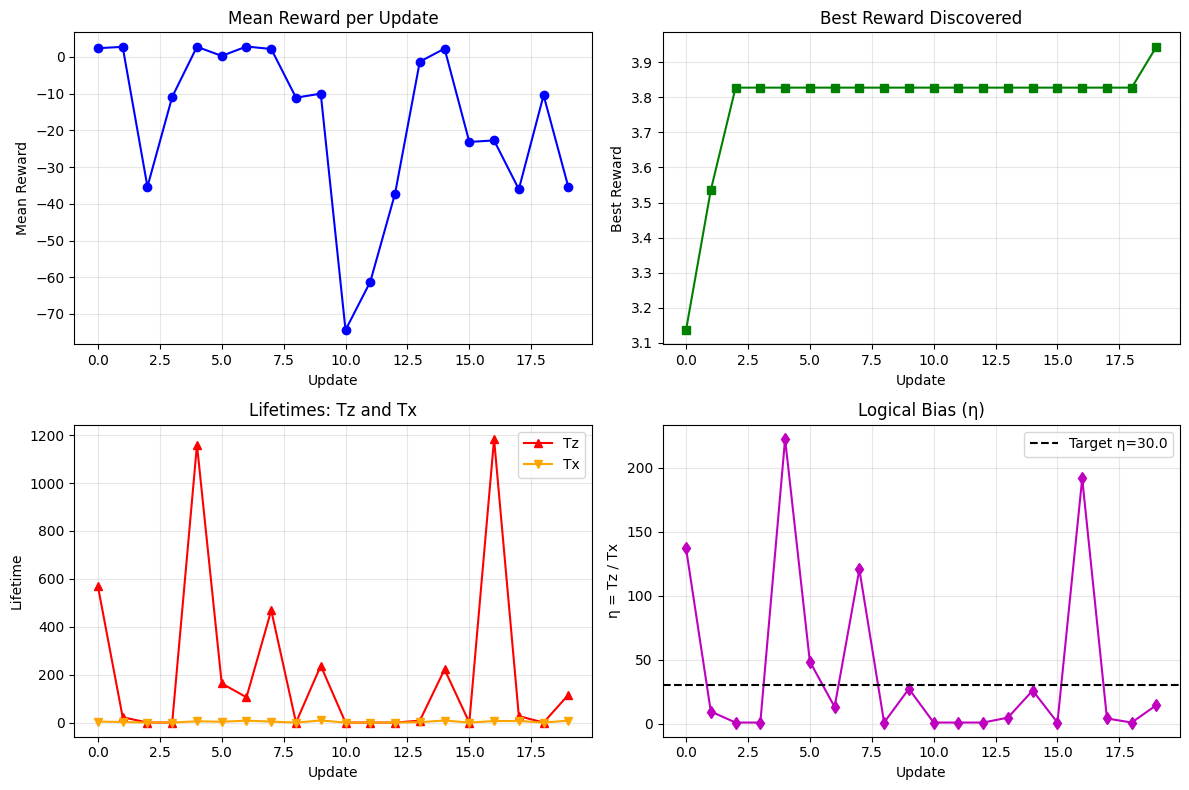

In [46]:
try:
    import matplotlib.pyplot as plt
    import json
    
    warnings.filterwarnings('ignore', category=UserWarning)
    cat_cfg = CatConfig(na=10, nb=3, kappa_b=10.0, kappa_a=0.05, target_eta=30.0)
    ppo_cfg = PPOConfig(total_updates=20, rollout_steps=8, ppo_epochs=4, minibatch_size=8)
    agent, best, history = train_ppo(cat_cfg, ppo_cfg)
    print("\nFINAL BEST")
    print(best)
    
    # Save history to JSON
    with open('training_history.json', 'w') as f:
        json.dump(history, f, indent=2)
    print("\nTraining history saved to training_history.json")
    
    # Plot training history
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Mean rewards
    axes[0, 0].plot(history['updates'], history['mean_rewards'], 'b-', marker='o')
    axes[0, 0].set_xlabel('Update')
    axes[0, 0].set_ylabel('Mean Reward')
    axes[0, 0].set_title('Mean Reward per Update')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Best reward over time
    axes[0, 1].plot(history['updates'], history['best_reward'], 'g-', marker='s')
    axes[0, 1].set_xlabel('Update')
    axes[0, 1].set_ylabel('Best Reward')
    axes[0, 1].set_title('Best Reward Discovered')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Lifetimes
    axes[1, 0].plot(history['updates'], history['last_Tz'], 'r-', label='Tz', marker='^')
    axes[1, 0].plot(history['updates'], history['last_Tx'], 'orange', label='Tx', marker='v')
    axes[1, 0].set_xlabel('Update')
    axes[1, 0].set_ylabel('Lifetime')
    axes[1, 0].set_title('Lifetimes: Tz and Tx')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Eta (bias)
    axes[1, 1].plot(history['updates'], history['last_eta'], 'm-', marker='d')
    axes[1, 1].axhline(y=cat_cfg.target_eta, color='k', linestyle='--', label=f'Target η={cat_cfg.target_eta}')
    axes[1, 1].set_xlabel('Update')
    axes[1, 1].set_ylabel('η = Tz / Tx')
    axes[1, 1].set_title('Logical Bias (η)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    print("Training plots saved to training_history.png")
    plt.show()
    
except Exception as e:
    print(f"Error occurred: {e}")
    import traceback
    traceback.print_exc()